In [ ]:
# Settings + Data fetching
system("conda install -y conda-forge::r-rcpp conda-forge::openssl conda-forge::r-sf conda-forge::r-terra conda-forge::r-ncdf4")
system("conda install -y conda-forge::r-lubridate conda-forge::r-rcolorbrewer conda-forge::r-lattice conda-forge::r-png r::r-raster")
system("conda install -y conda-forge::r-r.utils conda-forge::r-tidyverse conda-forge::libgdal-hdf5 conda-forge::r-ggplot2")
system("conda install conda-forge::r-fnn")
system("conda install conda-forge::r-cluster bioconda::r-bioregion")
system("conda install -y conda-forge::r-hrbrthemes conda-forge::r-viridis")


In [ ]:
library(R.utils)
library(tidyverse) # because who can live without the tidyverse?
library(dplyr)
library(tidyr)
library(utils)

library(ncdf4)
library(lubridate)
library(RColorBrewer)
library(lattice)

library(cluster)
library(data.table)
library(bioregion)
library(FNN)

library(terra)     
library(sf)        
library(ggplot2)

library(viridis)
library(hrbrthemes) 


Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, use, warnings


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   

In [ ]:
# SET DIRECTORIES
workdir <- getwd()
dataDir <- paste(workdir,"Data",sep = "/")
outputDir <- paste(workdir,"outputs/collection",sep = "/")
scriptDir <- paste(workdir,"scripts",sep = "/")

In [ ]:
# GENERAL FUNCTIONS

# ==============================================================================
# CREATE REPERTORY
# ==============================================================================
create.directory <- function(name.directory){
    ifelse(!dir.exists(file.path(name.directory)),
        dir.create(file.path(name.directory)),
        "Directory Exists")
}

# ==============================================================================
# DOWNLOAD FILENAME
# ==============================================================================
download.filename <- function(filename, url){
    options(timeout = 600)  # 10 minutes
    
    if(file.exists(filename)){
        cat(filename, "is (are) already in your repertory.")
    } else {
        download.file(url, filename, mode = "wb")
        print('File Downloaded')
    }
}

# ==============================================================================
# UNZIP FILENAME
# ==============================================================================
unzip.file <- function(filename, type = "gz"){
    filename.length <- nchar(filename)
    print(filename, filename.length)

    start <- 1

    if(type == "gz"){
        # Case Gunzip
        end <- filename.length-3
    }
    else{
        # Case Unzip
        end <- filename.length-4
    }

    unzip.filename <- substr(filename,start, end)
    print(unzip.filename)

    
    # Case gunzip
    if(!file.exists(unzip.filename)){
        if(type == "gz"){
            R.utils::gunzip(filename, overwrite=FALSE, remove=TRUE, BFR.SIZE=1e+07)
            }
        else{
            utils::unzip(filename, overwrite=FALSE )
            }
        cat(filename, "successfully unzipped!")
    }

    return(unzip.filename)
}

# ==============================================================================
# EXPORT AS A CSV 
# ==============================================================================
export.csv <- function(directory = outputDir, table.output, filename){
    table_filename <- paste(directory,filename, sep="/")
    write.table(table.output, table_filename, row.names=TRUE, col.names = TRUE, sep=",")
    print(paste(filename,"output exported.", sep = " "))
    }

# ==============================================================================
# MOVE TO DATA DIRECTORY 
# ==============================================================================
move.file <- function(filename, new.path){
    new.filename <- paste(new.path, filename, sep = "/")
    file.rename(from=filename, to=new.filename)
    return(new.filename)
}


,lon,lat,u,v
,<dbl>,<dbl>,<dbl>,<dbl>
1,-75,40,3.2,1.5
2,-74,41,2.8,0.9


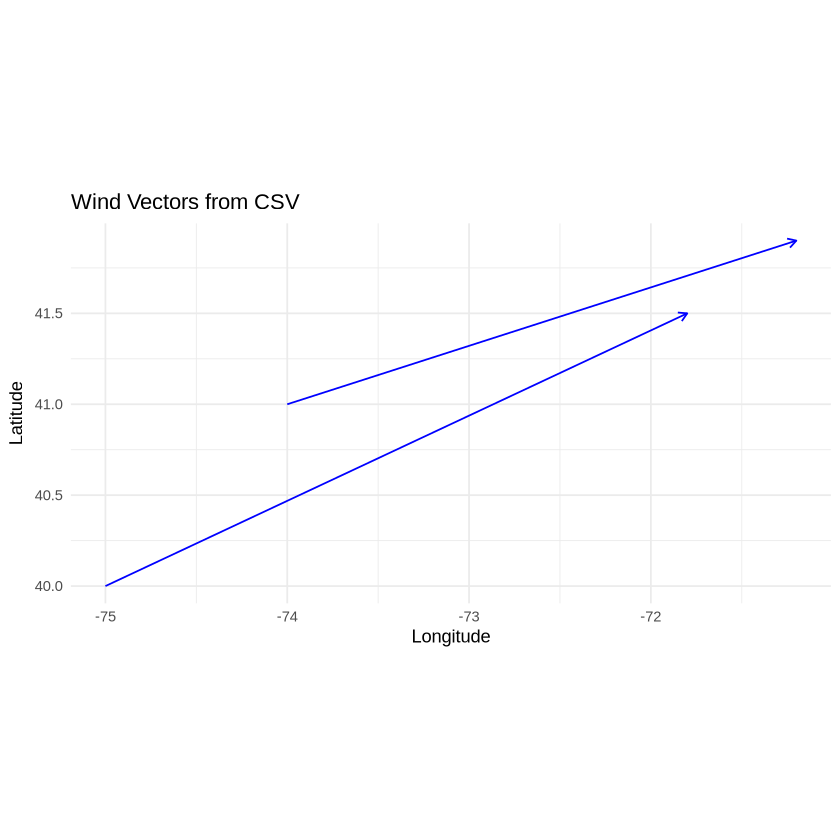

In [ ]:
# Read CSV file
# Example CSV structure:
wind_data <- rbind(c(-75,40,3.2,1.5), c(-74,41,2.8,0.9)) %>% as.data.frame
colnames(wind_data) <- c("lon","lat","u","v")
wind_data %>% head
# wind_data <- read.csv("wind_vectors.csv", stringsAsFactors = FALSE)

# Validate data
if (!all(c("lon", "lat", "u", "v") %in% names(wind_data))) {
  stop("CSV must contain columns: lon, lat, u, v")
}

# Quick plot of wind vectors
ggplot(wind_data, aes(x = lon, y = lat)) +
  geom_segment(aes(xend = lon + u, yend = lat + v),
               arrow = arrow(length = unit(0.2, "cm")),
               color = "blue") +
  coord_fixed() +
  theme_minimal() +
  labs(title = "Wind Vectors from CSV",
       x = "Longitude", y = "Latitude")


In [ ]:
# ==============================================================================
# WIND FILENAMES + URLS
# ==============================================================================
create.directory(dataDir)
windspeed.urls <- c("https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/wspd.mon.mean.nc",
                   "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/wspd.sig995.mon.1981-2010.ltm.nc",
                   "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/wspd.sig995.mon.ltm.1991-2020.nc")

windspeed.files <- c("wspd.mon.mean.nc",
                     "wspd.sig995.mon.ltm.1981-2010.nc",
                     "wspd.sig995.mon.ltm.1991-2020.nc")


vwind.urls <- c("https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/vwnd.sig995.mon.mean.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/vwnd.sig995.day.ltm.1981-2010.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/vwnd.sig995.day.ltm.1991-2020.nc")

vwind.files <- c("vwnd.sig995.mon.mean.nc",
                 "vwnd.sig995.day.ltm.1981-2010.nc",
                 "vwnd.sig995.day.ltm.1991-2020.nc")


uwind.urls <- c("https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/uwnd.sig995.mon.mean.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/uwnd.sig995.mon.ltm.1981-2010.nc",
                "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface/uwnd.sig995.mon.ltm.1991-2020.nc")

uwind.files <- c("uwnd.sig995.mon.mean.nc",
                 "uwnd.sig995.day.ltm.1981-2010.nc",
                 "uwnd.sig995.day.ltm.1991-2020.nc")


[1] TRUE

In [ ]:
i <- 1
download.filename(windspeed.files[i], windspeed.urls[i]) ; windspeed <- move.file(windspeed.files[i], dataDir)
download.filename(vwind.files[i], vwind.urls[i]) ; vwind <- move.file(vwind.files[i], dataDir)
download.filename(uwind.files[i], uwind.urls[i]) ; uwind <- move.file(uwind.files[i], dataDir)


[1] "File Downloaded"
[1] "File Downloaded"
[1] "File Downloaded"


In [ ]:
df_u %>% head()
df_v %>% head()
df_s %>% head()


,x,y,uwnd.sig995.mon.mean_1,uwnd.sig995.mon.mean_2,uwnd.sig995.mon.mean_3,uwnd.sig995.mon.mean_4,uwnd.sig995.mon.mean_5,uwnd.sig995.mon.mean_6,uwnd.sig995.mon.mean_7,uwnd.sig995.mon.mean_8,⋯,uwnd.sig995.mon.mean_929,uwnd.sig995.mon.mean_930,uwnd.sig995.mon.mean_931,uwnd.sig995.mon.mean_932,uwnd.sig995.mon.mean_933,uwnd.sig995.mon.mean_934,uwnd.sig995.mon.mean_935,uwnd.sig995.mon.mean_936,uwnd.sig995.mon.mean_937,uwnd.sig995.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,31.25,-61.64384,-1.40451443,1.144139,1.917421,1.032001,-0.5190307,-0.26233163,-0.5848364,0.47258291,⋯,0.06774299,0.3833342,-1.1508056,0.5774204,-0.3291655,-0.7895150,1.211668,1.005646,-9.96921e+36,-9.96921e+36
2,33.75,-61.64384,-0.74612725,1.683104,2.367100,1.450336,-0.3432248,-0.30233154,-0.2641926,0.59161526,⋯,-0.10161189,0.2191675,-0.9830635,0.6645170,0.1241678,-0.4725796,1.630001,1.252420,-9.96921e+36,-9.96921e+36
3,36.25,-61.64384,-0.21741609,2.174831,2.887099,1.892667,-0.1093519,-0.22899678,0.2264527,0.52225959,⋯,-0.16370860,0.3016675,-0.6217733,0.7540332,0.7416678,-0.1516118,2.077501,1.483872,-9.96921e+36,-9.96921e+36
4,38.75,-61.64384,0.06484050,2.338277,3.114518,2.054668,0.1158088,-0.09699758,0.7664539,0.29677606,⋯,-0.24193443,0.5150007,-0.1395152,0.6798397,1.1958344,-0.1008054,2.250001,1.496775,-9.96921e+36,-9.96921e+36
5,41.25,-61.64384,0.05161458,2.098623,2.954518,1.919670,0.3112926,0.06433563,1.2580645,0.11451721,⋯,-0.32499897,0.7825009,0.2596785,0.4322590,1.3908343,-0.3290312,2.216667,1.296775,-9.96921e+36,-9.96921e+36
6,43.75,-61.64384,-0.12645057,1.650347,2.617099,1.771334,0.5309684,0.22566731,1.6096792,0.09322874,⋯,-0.34757969,1.0591674,0.5064526,0.1233880,1.4916679,-0.5419345,2.274167,1.099194,-9.96921e+36,-9.96921e+36


,x,y,vwnd.sig995.mon.mean_1,vwnd.sig995.mon.mean_2,vwnd.sig995.mon.mean_3,vwnd.sig995.mon.mean_4,vwnd.sig995.mon.mean_5,vwnd.sig995.mon.mean_6,vwnd.sig995.mon.mean_7,vwnd.sig995.mon.mean_8,⋯,vwnd.sig995.mon.mean_929,vwnd.sig995.mon.mean_930,vwnd.sig995.mon.mean_931,vwnd.sig995.mon.mean_932,vwnd.sig995.mon.mean_933,vwnd.sig995.mon.mean_934,vwnd.sig995.mon.mean_935,vwnd.sig995.mon.mean_936,vwnd.sig995.mon.mean_937,vwnd.sig995.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,31.25,-61.64384,1.454196,0.835517645,0.001292075,1.0196697,1.0851632,-0.24466451,-1.351611,0.5619379,⋯,0.19032362,0.5050011,-0.16854751,0.85806555,2.501668,2.437904,3.964168,1.2661302,0.1185496,0.6125011
2,33.75,-61.64384,1.626132,0.421036303,-0.633224010,0.8736694,0.9041940,-0.03466542,-1.874837,0.6903248,⋯,0.28871062,0.5516676,0.03548487,0.83951700,2.483334,2.664517,3.945001,1.2532268,0.5088722,0.4767869
3,36.25,-61.64384,2.026455,0.116209358,-1.170321584,0.8146683,0.7712904,0.06766917,-2.495161,0.7706476,⋯,0.10403330,0.1858343,-0.06532171,0.63145262,2.152501,2.568549,3.528335,0.9943559,0.6411303,0.4285726
4,38.75,-61.64384,2.401936,-0.002757105,-1.424836636,0.8760020,0.6780671,0.13700256,-2.980322,0.8864534,⋯,-0.14354745,-0.3549989,-0.50403130,0.29838809,1.625834,2.298388,3.146668,0.7177429,0.5411302,0.4008940
5,41.25,-61.64384,2.667742,0.064140059,-1.385806203,1.0493327,0.6103230,0.20166931,-3.206450,1.0670989,⋯,-0.19516031,-0.7299989,-0.95161200,0.02258171,1.221668,2.234679,3.090835,0.6879042,0.4854850,0.4535725
6,43.75,-61.64384,2.830970,0.228966549,-1.177741289,1.2406697,0.5835497,0.23666839,-3.201612,1.2351625,⋯,-0.01370865,-0.8024990,-1.03306341,-0.05483774,1.107501,2.468550,3.283334,0.8943560,0.6338723,0.6062512


,x,y,wspd.mon.mean_1,wspd.mon.mean_2,wspd.mon.mean_3,wspd.mon.mean_4,wspd.mon.mean_5,wspd.mon.mean_6,wspd.mon.mean_7,wspd.mon.mean_8,⋯,wspd.mon.mean_929,wspd.mon.mean_930,wspd.mon.mean_931,wspd.mon.mean_932,wspd.mon.mean_933,wspd.mon.mean_934,wspd.mon.mean_935,wspd.mon.mean_936,wspd.mon.mean_937,wspd.mon.mean_938
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,31.25,-61.64384,4.279999,4.179993,4.709991,4.130005,4.229996,3.520004,3.910004,4.149994,⋯,3.518351,3.429198,3.337885,2.995759,4.199250,4.455856,4.938092,4.666928,-9.96921e+36,-9.96921e+36
2,33.75,-61.64384,4.250000,4.419998,4.860001,4.339996,4.009995,3.740005,4.069992,4.139999,⋯,3.859796,3.617950,3.391923,3.110649,4.264287,4.327250,5.054682,4.742764,-9.96921e+36,-9.96921e+36
3,36.25,-61.64384,4.509995,4.630005,5.179993,4.599991,3.759995,3.929993,4.410004,4.029999,⋯,4.186988,3.593628,3.514814,3.180423,4.044541,4.108964,5.059446,4.684937,-9.96921e+36,-9.96921e+36
4,38.75,-61.64384,4.729996,4.639999,5.300003,4.720001,3.490005,3.940002,4.619995,3.770004,⋯,4.199977,3.524929,3.458222,3.081492,3.795477,3.863228,4.982229,4.352719,-9.96921e+36,-9.96921e+36
5,41.25,-61.64384,4.830002,4.429993,5.190002,4.660004,3.380005,3.830002,4.660004,3.630005,⋯,4.020992,3.471993,3.527329,2.906749,3.808709,3.874980,4.959155,4.211573,-9.96921e+36,-9.96921e+36
6,43.75,-61.64384,4.910004,4.169998,5.130005,4.529999,3.429993,3.690002,4.610001,3.880005,⋯,3.979142,3.538637,3.646786,2.900402,4.086705,4.085295,5.124314,4.353256,-9.96921e+36,-9.96921e+36


In [ ]:
nlyr(u)
nlyr(v)
nlyr(speed)

time(u)[1:10]
time(v)[1:10]
time(speed)[1:10]

[1] 938

[1] 938

[1] 938

[1] NA NA NA NA NA NA NA NA NA NA

[1] NA NA NA NA NA NA NA NA NA NA

[1] NA NA NA NA NA NA NA NA NA NA

Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


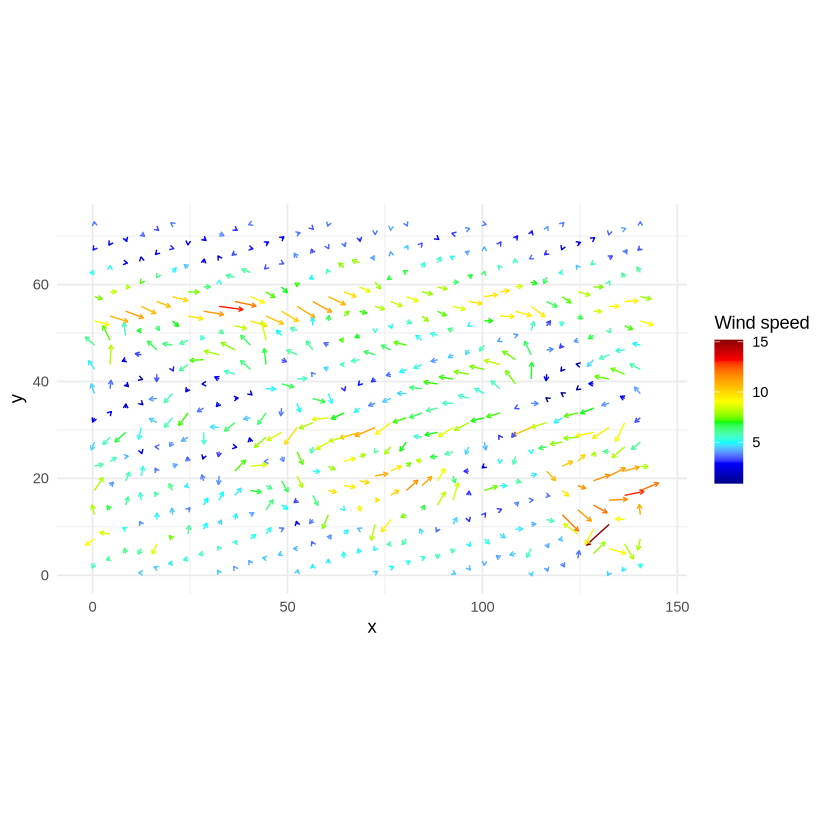

In [ ]:
# windspeed <- "Data/wspd.mon.mean.nc"
# vwind <- "Data/vwnd.sig995.mon.mean.nc"
# uwind <- "Data/uwnd.sig995.mon.mean.nc" 

# Load NetCDF files
u <- rast(uwind)
v <- rast(vwind)
speed <- rast(windspeed)  # optional (can compute instead)

# If needed: compute speed yourself
# speed <- sqrt(u^2 + v^2)

# Convert to dataframe
df_u <- as.data.frame(u, xy = TRUE)
df_v <- as.data.frame(v, xy = TRUE)
df_s <- as.data.frame(speed, xy = TRUE)

# Merge all
df <- df_u %>%
  rename(u = 3) %>%
  left_join(df_v %>% rename(v = 3), by = c("x", "y")) %>%
  left_join(df_s %>% rename(speed = 3), by = c("x", "y"))

# Optional: thin arrows (important for readability)
df_arrow <- df %>% 
  slice(seq(1, n(), by = 20))

colors <- length(unique(speed))
# Plot
ggplot(df_arrow) +
  geom_segment(aes(x = x, y = y,
                   xend = x + u * 0.5,
                   yend = y + v * 0.5,
                   color = speed),
               arrow = arrow(length = unit(0.1, "cm")),
               size = 0.4) +

  scale_color_gradientn(
    colours = c("dark blue", "blue", "cyan", "green", "yellow", "orange", "red", "dark red"),
    name = "Wind speed"
  ) +
  coord_quickmap() +
  theme_minimal()

In [ ]:
range(df$y) # latitude
range(df$x) # longitude

[1]  0.5 72.5

[1]   0.5 143.5

In [ ]:
nc <- nc_open(uwind)
print(nc)
nc_close(nc)

File /data/jwd07/pulsar_staging/110366079/working/jupyter/Data/uwnd.sig995.mon.mean.nc (NC_FORMAT_NETCDF4_CLASSIC):

     1 variables (excluding dimension variables):
        float uwnd[lon,lat,time]   (Chunking: [144,73,1])  (Compression: shuffle,level 2)
            long_name: Monthly Mean Zonal Wind at sigma level 0.995
            valid_range: -102.199996948242
             valid_range: 102.199996948242
            units: m/s
            add_offset: 0
            scale_factor: 1
            missing_value: -9.96920996838687e+36
            precision: 2
            least_significant_digit: 1
            var_desc: u-wind
            statistic: Mean
            parent_stat: Other
            dataset: NCEP Reanalysis Derived Products
            level_desc: 0.995 sigma
            actual_range: -18.8393516540527
             actual_range: 18.8058052062988

     3 dimensions:
        lat  Size:73 
            units: degrees_north
            actual_range: 90
             actual_range: -9

In [ ]:
urls_mpapd <- c(
  paste0("https://raw.githubusercontent.com/ccamlr/data/main/geographical_data/mpapd/CCAMLR_MPAPD_EPSG4326.",
         c("shp", "shx", "dbf", "prj")),
  paste0("https://raw.githubusercontent.com/ccamlr/data/main/geographical_data/mpapd/CCAMLR_MPAPD_EPSG6932.",
         c("shp", "shx", "dbf", "prj"))
)

lapply(urls_mpapd, function(u) {
  download.file(
    url = u,
    destfile = file.path(dataDir, basename(u)),
    mode = "wb"
  )
})

MPAPDs <- st_read(file.path(dataDir, "CCAMLR_MPAPD_EPSG4326.shp"))

# Reproject to the correct CRS --- 
if(crs(MPAPDs) != 4326){
    MPAPDs <- st_transform(MPAPDs, crs = 4326)
}


[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

[[4]]
[1] 0

[[5]]
[1] 0

[[6]]
[1] 0

[[7]]
[1] 0

[[8]]
[1] 0

Reading layer `CCAMLR_MPAPD_EPSG4326' from data source 
  `/data/jwd07/pulsar_staging/110366079/working/jupyter/Data/CCAMLR_MPAPD_EPSG4326.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 9 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -85.48797 xmax: 180 ymax: -45
Geodetic CRS:  WGS 84


In [ ]:
# Load NetCDF files
u <- rast(uwind)
v <- rast(vwind)
speed <- rast(windspeed)  # optional (can compute instead)

# Read shapefile (EPSG:4326 version is easiest)
mpa <- vect(file.path(dataDir, "CCAMLR_MPAPD_EPSG4326.shp"))


Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”


## Option A — Mask the raster (keep only inside polygons)

In [ ]:
# --------------------------------------------------
# CRS
# --------------------------------------------------
crs(u) <- "EPSG:4326"
crs(v) <- "EPSG:4326"
crs(speed) <- "EPSG:4326"

# --------------------------------------------------
# Check raster
# --------------------------------------------------
print(ext(u))
print(ext(v))

# --------------------------------------------------
# Define target region
# 30–150°E, 70–60°S
# --------------------------------------------------
ext_crop <- ext(30, 150, -70, -60)

print(ext_crop)

# Check that they overlap
print(terra::intersect(ext(u), ext_crop))

# --------------------------------------------------
# Make sure MPA is in the same CRS as the raster
# --------------------------------------------------
mpa <- project(mpa, crs(u))

# --------------------------------------------------
# Crop first
# --------------------------------------------------
u_crop <- terra::crop(u, ext_crop)
v_crop <- terra::crop(v, ext_crop)
speed_crop <- terra::crop(speed, ext_crop)

# Check
print(u_crop)
print(ext(u_crop))
# --------------------------------------------------
# Mask
# --------------------------------------------------
u_masked <- mask(u_crop, mpa)
v_masked <- mask(v_crop, mpa)
speed_masked <- mask(speed_crop, mpa)

# --------------------------------------------------
# Convert to data frames
# --------------------------------------------------
df_u <- as.data.frame(u_masked, xy = TRUE, na.rm = TRUE)
df_v <- as.data.frame(v_masked, xy = TRUE, na.rm = TRUE)
df_s <- as.data.frame(speed_masked, xy = TRUE, na.rm = TRUE)

SpatExtent : 0, 144, 0, 73 (xmin, xmax, ymin, ymax)
SpatExtent : 0, 144, 0, 73 (xmin, xmax, ymin, ymax)
SpatExtent : 30, 150, -70, -60 (xmin, xmax, ymin, ymax)
NULL


ERROR: Error: [crop] extents do not overlap


In [ ]:
df_u <- as.data.frame(u_crop,
                      xy = TRUE,
                      na.rm = TRUE)
df_v <- as.data.frame(v_crop,
                      xy = TRUE,
                      na.rm = TRUE)
df_s <- as.data.frame(speed_crop,
                      xy = TRUE,
                      na.rm = TRUE)

df <- data.frame(lon = df_u$x,
                 lat = df_u$y,
                 u = df_u[[3]],
                 v = df_v[[3]],
                 speed = df_s[[3]])

ggplot() +
    # Antarctica / MPAs
    geom_sf(data = MPAPDs
            fill = "grey85",
            color = "black",
        linewidth = 0.2) +
    # Wind vectors
    geom_segment(data = df,
        aes(x = lon,
            y = lat,
            xend = lon + u * 0.4,
            yend = lat + v * 0.4,
            color = speed),
        arrow = arrow(length = unit(0.08, "cm"),
                      type = "closed"),
        linewidth = 0.3) +
    scale_color_viridis_c(name = "Wind speed") +
    coord_sf(xlim = c(30, 150),
             ylim = c(-70, -60),
             expand = FALSE) +
labs(x = "Longitude",
         y = "Latitude") +
    theme_minimal()

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': object 'u_crop' not found


In [ ]:
# --------------------------------------------------
# Mask
# --------------------------------------------------
u_masked <- mask(u_crop, mpa)
v_masked <- mask(v_crop, mpa)
speed_masked <- mask(speed_crop, mpa)

# --------------------------------------------------
# Convert to data frames
# --------------------------------------------------
df_u <- as.data.frame(u_masked, xy = TRUE, na.rm = TRUE)
df_v <- as.data.frame(v_masked, xy = TRUE, na.rm = TRUE)
df_s <- as.data.frame(speed_masked, xy = TRUE, na.rm = TRUE)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'mask': object 'u_crop' not found


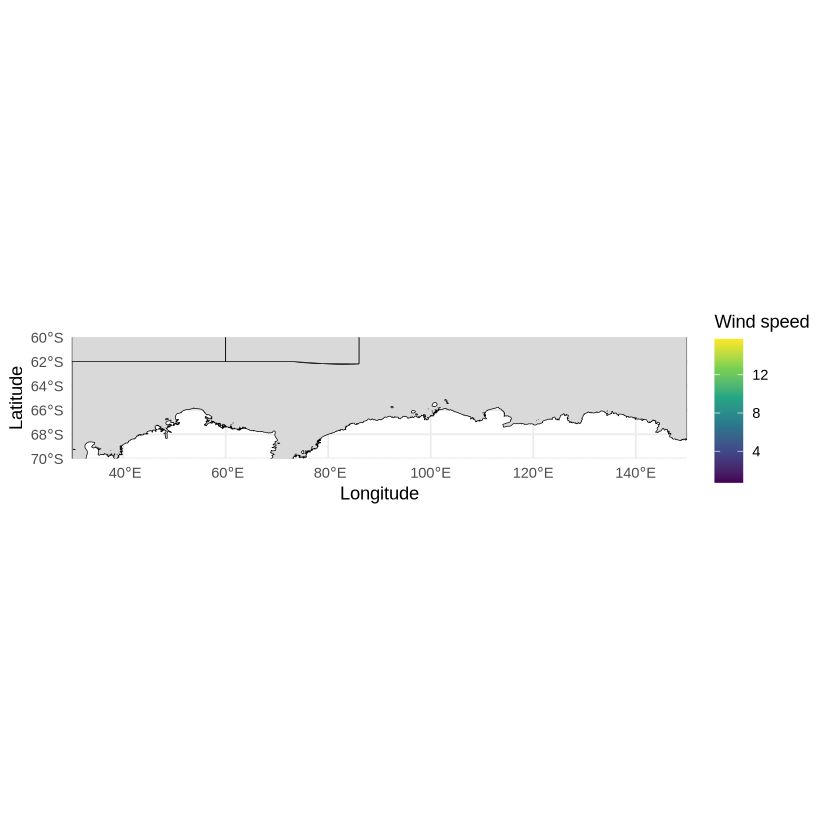

In [ ]:
df <- data.frame(
    lon = df_u$x, lat = df_u$y,
    u = df_u[[3]], v = df_v[[3]],
    speed = df_s[[3]])

ggplot() +
    # Antarctica / MPAs
    geom_sf(data = MPAPDs,
        fill = "grey85",
        color = "black",
        linewidth = 0.2) +
    # Wind vectors
    geom_segment(data = df,
        aes(x = lon, y = lat,
            xend = lon + u * 0.4,
            yend = lat + v * 0.4,
            color = speed),
        arrow = arrow(
            length = unit(0.08, "cm"),
            type = "closed"),
        linewidth = 0.3) +
    scale_color_viridis_c(name = "Wind speed") +
    coord_sf(
        xlim = c(30, 150),
        ylim = c(-70, -60),
        expand = FALSE) +
    labs(x = "Longitude", y = "Latitude") +
    theme_minimal()

In [ ]:
df <- merge(df_u,
            df_v,
            by = c("x", "y"))

df <- merge(df,
            df_s,
            by = c("x", "y"))

# names(df)

ggplot() +

    # MPA polygons
    geom_sf(
        data = MPAPDs,
        fill = "grey85",
        color = "black",
        linewidth = 0.2
    ) +

    # Wind vectors
    geom_segment(data = df,
                 aes(x = lon,
                     y = lat,
                     xend = lon + u * 0.4,
                     yend = lat + v * 0.4,
                     color = speed),
                 arrow = arrow(length = unit(0.08, "cm"),
                               type = "closed"),
                 linewidth = 0.3) +
    scale_color_viridis_c(name = "Wind speed") +
    coord_sf(xlim = c(30, 150),
             ylim = c(-70, -60),
             expand = FALSE) +
    labs(x = "Longitude",
         y = "Latitude") +
    theme_minimal()

ERROR while rich displaying an object: Error in `geom_segment()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 2nd layer.
Caused by error:
! object 'lon' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 . 

In [ ]:
ext_crop <- terra::ext(30, 150, -70, -60)

print(terra::ext(u))
print(ext_crop)

terra::intersect(terra::ext(u), ext_crop)

SpatExtent : 0, 144, 0, 73 (xmin, xmax, ymin, ymax)
SpatExtent : 30, 150, -70, -60 (xmin, xmax, ymin, ymax)


NULL

In [ ]:
# Load NetCDF files
u <- rast(uwind)
v <- rast(vwind)
speed <- rast(windspeed)

# Correct the spatial extent of the NCEP 144 x 73 grid
ext(u) <- ext(0, 360, -90, 90)
ext(v) <- ext(0, 360, -90, 90)
ext(speed) <- ext(0, 360, -90, 90)

# Set geographic CRS
crs(u) <- "EPSG:4326"
crs(v) <- "EPSG:4326"
crs(speed) <- "EPSG:4326"

# Read MPA shapefile
mpa <- vect(file.path(dataDir, "CCAMLR_MPAPD_EPSG4326.shp"))

# Make sure MPA has same CRS
mpa <- project(mpa, crs(u))

# Desired region:
# 30–150°E, 70–60°S
ext_crop <- ext(30, 150, -70, -60)

# Crop first
u_crop <- crop(u, ext_crop)
v_crop <- crop(v, ext_crop)
speed_crop <- crop(speed, ext_crop)

# Then mask by MPA
u_masked <- mask(u_crop, mpa)
v_masked <- mask(v_crop, mpa)
speed_masked <- mask(speed_crop, mpa)

# Convert to data frames
df_u <- as.data.frame(u_masked, xy = TRUE, na.rm = TRUE)
df_v <- as.data.frame(v_masked, xy = TRUE, na.rm = TRUE)
df_s <- as.data.frame(speed_masked, xy = TRUE, na.rm = TRUE)

Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”
Warning message:
“[rast] unknown extent”


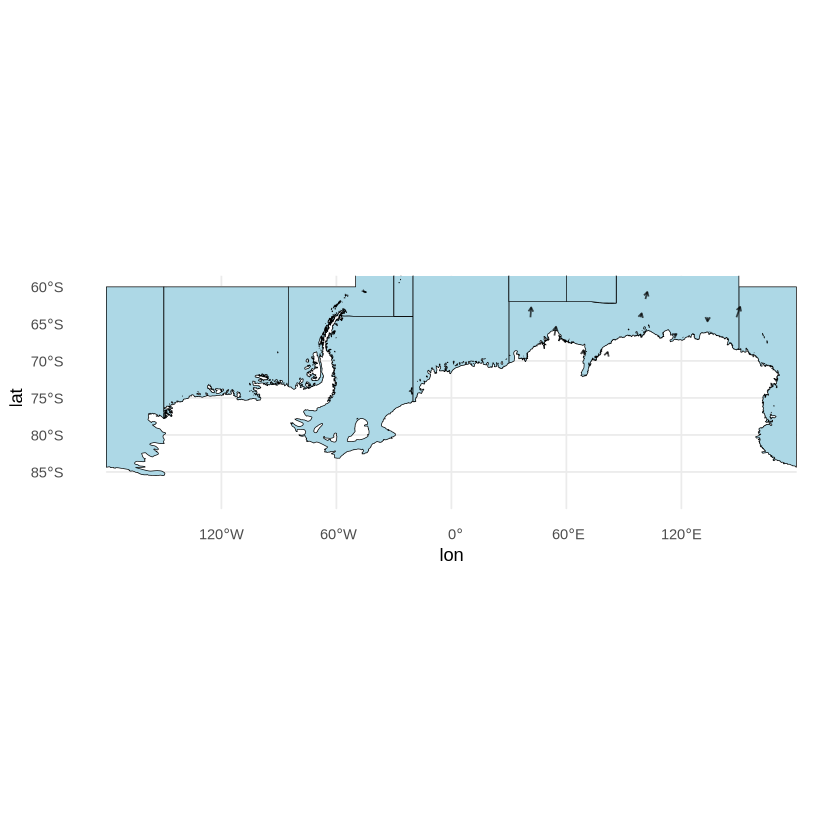

In [ ]:
crs(u) <-"EPSG:4326"
crs(v) <- crs(speed) <- crs(u)

##################################
# Merge u and v into one dataframe
##################################
df <- merge(df_u, df_v, by = c("x", "y"))

# Rename for clarity (adjust depending on layer names)
colnames(df) <- c("lon", "lat", "u", "v")

##################################
# Thin the vectors (VERY important)
##################################
df_thin <- df[seq(1, nrow(df), by = 20), ]

##################################
# Plot Antarctica + MPAs + wind vectors
##################################
df_thin <- df[seq(1, nrow(df), by = 20), ]

mpa_sf <- st_as_sf(mpa)

ggplot() +
  geom_sf(data = mpa_sf, fill = "lightblue", color = "black") +

  geom_segment(data = df_thin,
               aes(x = lon, y = lat,
                   xend = lon + u * 0.5,
                   yend = lat + v * 0.5),
               arrow = arrow(length = unit(0.1, "cm")),
               alpha = 0.7) +

  coord_sf(xlim = c(-180, 180), ylim = c(-90, -60)) +
  theme_minimal()

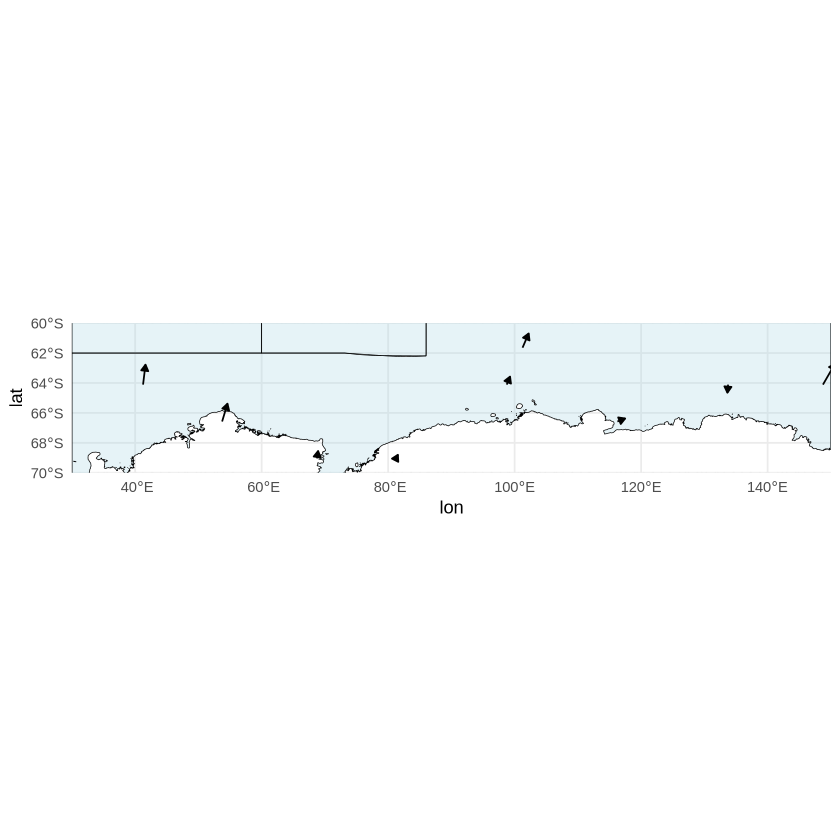

In [ ]:
crs(u) <-"EPSG:4326"
crs(v) <- crs(speed) <- crs(u)

##################################
# Merge u and v
##################################
df <- merge(df_u, df_v, by = c("x", "y"))
colnames(df) <- c("lon", "lat", "u", "v")

##################################
# Thin vectors
##################################
df_thin <- df[seq(1, nrow(df), by = 20), ]

##################################
# Convert MPA to sf
##################################
mpa_sf <- st_as_sf(mpa)

##################################
# Plot
##################################

ggplot() +
  # MPA polygons -- background
  geom_sf(data = mpa_sf,
          fill = "lightblue",
          color = "black",
          alpha = 0.3) +
  # Wind arrows -- FOREGROUND
  geom_segment(data = df_thin,
               aes(x = lon,
                   y = lat,
                   xend = lon + u * 0.5,
                   yend = lat + v * 0.5),
               color = "black",
               linewidth = 0.5,
               alpha = 1,
    arrow = arrow(length = unit(0.15, "cm"),
                  type = "closed")) +
  coord_sf(xlim = c(30, 150),
           ylim = c(-70, -60),
           expand = FALSE) +
  theme_minimal()

In [ ]:
ggplot() +
  geom_raster(data = df_s, aes(x = x, y = y, fill = speed)) +
  geom_sf(data = mpa_sf, fill = NA, colour = "black") +
  geom_segment(
    data = df_wind,
    aes(
      x = x, y = y,
      xend = x + u * scale,
      yend = y + v * scale
    ),
    arrow = arrow(length = unit(0.15, "cm")),
    linewidth = 0.4
  )

ERROR: Error: object 'df_wind' not found


## Option B — Convert raster → points and spatial join (most flexible)

In [ ]:
crs(u) <-"EPSG:4326"
crs(v) <- crs(speed) <- crs(u)

# Convert raster to points
pts <- as.points(u)  # or speed
pts_sf <- st_as_sf(pts)

sf_use_s2(FALSE)
# Convert MPA to sf
mpa_sf <- st_as_sf(mpa)
mpa_sf <- st_make_valid(mpa_sf)

# Transform points to match shapefile CRS
pts_sf <- st_transform(pts_sf, st_crs(mpa_sf))


Spherical geometry (s2) switched off



In [ ]:
df_u %>% head()
df_v %>% head()
df_s %>% head()

df %>% head()


In [ ]:
library(ncdf4)

# Open NetCDF file

nc <- nc_open(windspeed)

# Read variables (names depend on your dataset)
lon <- ncvar_get(nc, "lon")
lat <- ncvar_get(nc, "lat")
u <- ncvar_get(nc, "u10")  # U-component at 10m
v <- ncvar_get(nc, "v10")  # V-component at 10m

nc_close(nc)

# Flatten into a data frame
wind_df <- expand.grid(lon = lon, lat = lat)
wind_df$u <- as.vector(u)
wind_df$v <- as.vector(v)

# Plot
library(ggplot2)
ggplot(wind_df, aes(x = lon, y = lat)) +
  geom_segment(aes(xend = lon + u, yend = lat + v),
               arrow = arrow(length = unit(0.15, "cm")),
               color = "red") +
  coord_fixed() +
  theme_minimal() +
  labs(title = "Wind Vectors from NetCDF",
       x = "Longitude", y = "Latitude")


In [ ]:
wind_df$speed <- sqrt(wind_df$u^2 + wind_df$v^2)
wind_df$direction <- (atan2(wind_df$u, wind_df$v) * 180 / pi + 360) %% 360


In [ ]:
wind

ERROR: Error: object 'wind' not found


In [ ]:
wind <- c(u, v, speed)
names(wind) <- c("u", "v", "speed")

df <- as.data.frame(wind, xy = TRUE, na.rm = TRUE)

# Subsample for arrows
df_arrow <- df %>%
  slice(seq(1, n(), by = 20))

In [ ]:
ggplot() +
  geom_sf(data = mpa_sf, fill = NA, color = "black", size = 0.3) +
  geom_segment(data = df_arrow,
               aes(x = x, y = y,
                   xend = x + u * 0.5,
                   yend = y + v * 0.5,
                   color = speed),
               arrow = arrow(length = unit(0.1, "cm")),
               size = 0.4) +
  scale_color_gradientn(
    colours = c("dark blue", "blue", "cyan", "green", "yellow", "orange", "red", "dark red"),
    name = "Wind speed"
  ) +
  coord_sf() +
  theme_minimal()

https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html
* 

https://www.ncei.noaa.gov/products/international-comprehensive-ocean-atmosphere-data-set
* https://www.ncei.noaa.gov/data/international-comprehensive-ocean-atmosphere/v3/archive/nrt/monthly/


In [ ]:
# Load required libraries
library(ncdf4)         # To read netCDF files
library(ggplot2)       # For plotting
library(viridis)       # For color scales in the plot
library(sf)            # For handling spatial objects
library(rnaturalearth) # For retrieving coastline data
library(rnaturalearthdata)

In [ ]:
# Defined locations
netcdf_file <- "path/to/your/file.nc"       # Full path to the netCDF file
output_dir  <- "path/to/your/directory/"   # Output directory to save the map

In [ ]:
# Names of variables in the netCDF file (modify according to your file)
var_lon <- "longitude"  # Variable name for longitude
var_lat <- "latitude"   # Variable name for latitude
var_u   <- "uo"         # Variable name for the u component of current
var_v   <- "vo"         # Variable name for the v component of current

In [ ]:
# Open the netCDF file
nc_data <- nc_open(netcdf_file)

# Extract the data (variable names and dimensions may vary)
lon <- ncvar_get(nc_data, var_lon)
lat <- ncvar_get(nc_data, var_lat)
u   <- ncvar_get(nc_data, var_u)
v   <- ncvar_get(nc_data, var_v)

# Close the netCDF file
nc_close(nc_data)

In [ ]:
# Verify that dimensions match (assuming a grid of lon x lat)
if (length(lon) * length(lat) != length(u)) {
  stop("Variable dimensions do not match. Check your netCDF file.")
}

In [ ]:
# Create a grid with all combinations of lon and lat
grid <- expand.grid(lon = lon, lat = lat)

In [ ]:
# Assign the u and v values to the grid (convert to vectors)
grid$u <- as.vector(u)
grid$v <- as.vector(v)
grid$speed <- sqrt(grid$u^2 + grid$v^2)  # Calculate current speed

# Adjust 'skip' to modify the number of arrows plotted
skip <- 10
grid_subset <- grid[seq(1, nrow(grid), by = skip), ]

# Determine geographic extent for plotting
min_lon <- min(grid$lon, na.rm = TRUE)
max_lon <- max(grid$lon, na.rm = TRUE)
min_lat <- min(grid$lat, na.rm = TRUE)
max_lat <- max(grid$lat, na.rm = TRUE)

In [ ]:
## ---- Loading Coastline Data ----
# Load coastline data using rnaturalearth
world <- ne_countries(scale = "medium", returnclass = "sf")

In [ ]:
p <- ggplot() +
  geom_sf(data = world, fill = NA, color = "black", linewidth = 0.5) +
  geom_segment(
    data = grid_subset,
    aes(x = lon, y = lat, xend = lon + u, yend = lat + v, color = speed),
    # Adjust arrow size by modifying the length (e.g., unit(0.15, "cm") to another value)
    arrow = arrow(length = unit(0.15, "cm")),
    # Adjust arrow thickness by changing 'linewidth'
    linewidth = 0.5
  ) +
  # Change the color gradient by modifying the 'option' parameter in scale_color_viridis (e.g., "magma", "inferno", etc.)\n  scale_color_viridis(option = "plasma") +
  coord_sf(xlim = c(min_lon, max_lon), ylim = c(min_lat, max_lat), expand = FALSE) +
  theme_minimal() +
  labs(
    title = "Ocean Current Vectors (Subset)",  # Modify the title as needed
    x = "Longitude",
    y = "Latitude",
    color = "Speed (m/s)"
  )

print(p)

In [ ]:
output_file <- file.path(output_dir, "ocean_current_vectors.png")
ggsave(output_file, p, width = 15, height = 12, dpi = 300)